# Librerias y variables

In [5]:
!pip install -q mediapipe

In [6]:
import os
import cv2
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import mediapipe as mp
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from keras.api.models import Model, clone_model
from keras.api.utils import to_categorical
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from matplotlib.ticker import MaxNLocator
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from keras.api.applications import VGG16, ResNet50, EfficientNetB0, NASNetMobile
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.api.preprocessing.image import load_img, img_to_array
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, matthews_corrcoef, roc_curve)
from keras.api.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D


In [7]:
POPULATION = [20, 10, 5, 3, 1]
DIRECTORY_IMG = "/kaggle/input/peruvian-sign-language-alphabet/data/images"
DIRECTORY_CSV = "/kaggle/input/peruvian-sign-language-alphabet/data/labels.csv"
DIRECTORY_RESULTS = "/kaggle/working/results.csv"
DIRECTORY_GENERATIONS = "/kaggle/working/generations.csv"

In [8]:
DF_RESULTS = pd.DataFrame(columns=["n_cnn", "n_dense", "i_cnn", "i_dense", 
                           "batch_normalization", "max_pool", "dropout", 
                           "accuracy", "precision", "recall", "f1_score", 
                           "AUC_ROC", "MCC", "time", "generation", "reward"])
DF_RESULTS.to_csv(DIRECTORY_RESULTS, index=False)

DF_GENERATIONS = pd.DataFrame(columns=["n_cnn", "n_dense", "i_cnn", "i_dense", 
                                       "batch_normalization", "max_pool", "dropout", 
                                       "generation"])
DF_GENERATIONS.to_csv(DIRECTORY_GENERATIONS, index=False)

LABELS_SIGN = [chr(i) for i in range(65, 90) if chr(i) not in ['J']]
NAMES_PARAMETERS = ["n_cnn", "n_dense", "i_cnn", "i_dense", "batch_normalization", "max_pool", "dropout"]

In [ ]:
CLASSIFIERS = [
    KNeighborsClassifier(n_neighbors=5),
    ExtraTreesClassifier(n_estimators=200, max_depth=20, min_samples_split=10, min_samples_leaf=2, max_features='sqrt'),
    RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=10, min_samples_leaf=2, max_features='sqrt')    
]

MODELS = [
    VGG16(weights='imagenet', include_top=False, input_shape=(100, 100, 3)),
    ResNet50(weights='imagenet', include_top=False, input_shape=(100, 100, 3)),
    EfficientNetB0(weights='imagenet', include_top=False, input_shape=(100, 100, 3)),
    NASNetMobile(weights='imagenet', include_top=False, input_shape=(100, 100, 3))
]

warnings.simplefilter("ignore")

# Crear set de datos

In [3]:
def create_dataset(directory, shape=224):
    hands = mp.solutions.hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)
    video = cv2.VideoCapture(0)
    img_total = 0
    loop = True
    label = ""

    try:
        df = pd.read_csv(f"{directory}/labels.csv")
        img_total = len(df)
    except:
        df = pd.DataFrame(columns=['image', 'label'])        

    while loop:    
        label = input("Enter the letter: ")
        
        if label != "ESC":
            img_per_label = 0

            while img_per_label < 100:
                difference = 0
                ret, frame = video.read()
                height, width, _ = frame.shape
                if not ret:
                    continue
                results = hands.process(frame)

                if results.multi_hand_landmarks:
                    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
                    for i in range(21):
                        landmarks = results.multi_hand_landmarks[0].landmark
                        punto = landmarks[i]
                        x = punto.x
                        y = punto.y
                        xmin = min(x, xmin)
                        xmax = max(x, xmax)
                        ymin = min(y, ymin)
                        ymax = max(y, ymax)

                    xmin = int(xmin * width)
                    xmax = int(xmax * width)
                    ymin = int(ymin * height)
                    ymax = int(ymax * height)

                    if (xmax - xmin) <= (ymax - ymin):
                        difference = ymax - ymin
                    else:
                        difference = xmax - xmin

                    ymin_recorte = max(ymin - int(difference * 0.25), 0)
                    ymax_recorte = min(ymin + int(difference * 1.25), frame.shape[0])
                    xmin_recorte = max(xmin - int(difference * 0.25), 0)
                    xmax_recorte = min(xmin + int(difference * 1.25), frame.shape[1])

                    recorte = frame[ymin_recorte:ymax_recorte, xmin_recorte:xmax_recorte]

                    height, width, _ = recorte.shape
                    if recorte.size > 0 and height > shape and width > shape:
                        recorte = cv2.resize(recorte, (shape, shape))
                        df.loc[len(df)] = [f"{img_total}.jpg", label]
                        cv2.imwrite(f"{directory}/images/{img_total}.jpg", recorte)
                        img_per_label += 1
                        img_total += 1
                        cv2.rectangle(frame, (xmin_recorte, ymin_recorte), (xmax_recorte,ymax_recorte ), (0, 255, 0), 2)
                    else:
                        cv2.rectangle(frame, (xmin_recorte, ymin_recorte), (xmax_recorte,ymax_recorte ), (0, 0, 255), 2)
                
                cv2.imshow('Create dataset', frame)

                if cv2.waitKey(1) & 0xFF == 27:
                    break

            df.to_csv(f"{directory}/labels.csv", index=False)
        else:
            loop = False

    video.release()
    cv2.destroyAllWindows()

#create_dataset("data")
        

# Funciones

## Procesamiento de datos

In [10]:
def get_data(shape_img=100, img_per_label=100):
    df_imgs = pd.read_csv(DIRECTORY_CSV)
    max_original = img_per_label * len(LABELS_SIGN)
    
    image_files = [os.path.join(DIRECTORY_IMG, i) for i in os.listdir(DIRECTORY_IMG) if i.endswith(('.jpg', '.png'))]
    random.shuffle(image_files)
    
    images, labels = [], []
    for img_file in image_files:
        if len(images) < max_original:
            try:
                name_img = img_file.split("/")[-1]
                name_label = df_imgs.loc[df_imgs['image'] == name_img, 'label']
                if name_label.empty:
                    continue
                
                name_label = name_label.values[0]
                for idx, lab in enumerate(LABELS_SIGN):
                    if lab == name_label and labels.count(idx) < img_per_label:
                        image = img_to_array(load_img(img_file, target_size=(shape_img, shape_img)))
                        images.append(image)
                        labels.append(idx)
                        break
            except Exception:
                continue

    for class_idx in range(len(LABELS_SIGN)):
        while labels.count(class_idx) < img_per_label:
            valid_indices = [i for i, lab in enumerate(labels) if lab == class_idx]
            if valid_indices:
                idx = random.choice(valid_indices)
                images.append(images[idx])
                labels.append(labels[idx])
            else:
                break

    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)
    
    labels_enc = LabelEncoder().fit_transform(labels)
    x_train, x_test, y_train, y_test = train_test_split(images, labels_enc, test_size=0.2, random_state=42)
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)    
    
    return {
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test
    }

## Genetico

In [ ]:
def generate_individual(max_cnn=5, max_dense=5):
    i_layers = [2 ** (i + 2) for i in range(8)]

    n_cnn = random.randint(-3, max_cnn)
    n_dense = random.randint(-2, max_dense)

    parameter = {
        "n_cnn": n_cnn, # VGG16(0), ResNet(-3), EfficientNet(-2), nasnet(-1)
        "n_dense": n_dense, # KNN (0), extra trees(-2), random forest(-1)

        "i_cnn": i_layers[:4][random.randint(0, 3)] if n_cnn > 0 else 0,
        "i_dense": i_layers[-4:][random.randint(0, 3)] if n_dense > 0 else 0,

        "batch_normalization": [random.randint(0, 1) for _ in range(n_cnn)] if n_cnn > 0 else [],
        "max_pool": [random.randint(0, 1) for _ in range(n_cnn)] if n_cnn > 0 else [],
        "dropout": [random.randint(0, 1) for _ in range(n_dense)] if n_dense > 0 else []
    }
    
    return parameter

def verify_individual(individual):
    if individual['n_cnn'] > 0 and individual['i_cnn'] <= 0:
        return False

    if individual['n_dense'] > 0 and individual['i_dense'] <= 0:
        return False
    
    if individual['n_cnn'] > 0 and (len(individual['batch_normalization']) <= 0  or len(individual['max_pool']) <= 0):
        return False

    if individual['n_dense'] > 0 and len(individual['dropout']) <= 0:
        return False

    return True


def create_initial_population():
    print(f"Generation: 0")
    initial_population = []
    while len(initial_population) < POPULATION[0]:
        individual = generate_individual()
        if verify_individual(individual):
            reward = fitness(individual, 0, 0.1)
            if reward > 0.1:
                update_population(individual, 0)
                initial_population.append(individual)
            
            DF_RESULTS.to_csv(DIRECTORY_RESULTS, index=False)
            DF_GENERATIONS.to_csv(DIRECTORY_GENERATIONS, index=False)
    print(f"Best reward: {DF_RESULTS[DF_RESULTS['generation'] == 0]['reward'].max()}\n")

def selection(generation, n_largest):
    df = DF_RESULTS[DF_RESULTS['generation'] == generation].nlargest(n_largest, 'accuracy')
    df = df[['n_cnn', 'n_dense', 'i_cnn', 'i_dense', 'batch_normalization', 'max_pool', 'dropout']]
    selected_population = []
    for i in range(len(df)):
        parameter = {}
        for n, name in enumerate(NAMES_PARAMETERS): 
            parameter[name] = int(df.iloc[i][name]) if n < 4 else df.iloc[i][name]
            
        selected_population.append(parameter)
    
    return selected_population

def crossing(parents):
    parents = random.sample(parents, 2)
    son = {name: 0 for name in NAMES_PARAMETERS[:4]}
    son.update({name: [] for name in NAMES_PARAMETERS[4:]})
    
    random.shuffle(parents)
    for i in range(2):
        son[NAMES_PARAMETERS[i]] = parents[i][NAMES_PARAMETERS[i]]
    
    if son[NAMES_PARAMETERS[0]] > 0 and son[NAMES_PARAMETERS[1]] > 0:
        random.shuffle(parents)
        for param, start_idx in [("n_cnn", 4), ("n_dense", 6)]:
            max_val = max(parents[0][param], parents[1][param])
            for i in range(start_idx, start_idx + 2):
                if i > 6:
                    break
                if max_val == 1:
                    son[NAMES_PARAMETERS[i]] = parents[0][NAMES_PARAMETERS[i]]
                else:
                    crossing_point = random.randint(1, max_val - 1)
                    l_base = son[param]
                    result = parents[0][NAMES_PARAMETERS[i]][:crossing_point] + parents[1][NAMES_PARAMETERS[i]][crossing_point:]
                    son[NAMES_PARAMETERS[i]] = (result + [random.randint(0, 1) for _ in range(l_base - len(result))])[:l_base]
        for i in range(2):            
            param = random.choice(parents)[NAMES_PARAMETERS[i + 2]]
            while param <= 0:
                param = random.choice(parents)[NAMES_PARAMETERS[i + 2]]
            son[NAMES_PARAMETERS[i + 2]] = param

    else:
        son[NAMES_PARAMETERS[2]] = parents[0][NAMES_PARAMETERS[2]]
        son[NAMES_PARAMETERS[3]] = parents[1][NAMES_PARAMETERS[3]]
        son[NAMES_PARAMETERS[4]] = parents[0][NAMES_PARAMETERS[4]]
        son[NAMES_PARAMETERS[5]] = parents[0][NAMES_PARAMETERS[5]]
        son[NAMES_PARAMETERS[6]] = parents[1][NAMES_PARAMETERS[6]]
    
    return son

def mutation(individual, max_cnn=5, max_dense=5):
    try:
        individual_final = individual
        
        i_layers = [2 ** (i + 2) for i in range(8)]
        g        = random.randint(0, 6)
        
        if g == 0:
            individual_final["n_cnn"] = random.randint(-3, max_cnn)
            if individual_final['n_cnn'] <= 0:
                individual_final['i_cnn'] = 0
                individual_final['batch_normalization'] = []
                individual_final['max_pool'] = []
            else:
                for key in ("batch_normalization", "max_pool"):
                    diff = individual_final["n_cnn"] - len(individual_final[key])
                    individual_final[key] = (individual_final[key] + [random.randint(0, 1) for _ in range(diff)])[:individual_final["n_cnn"]]

        elif g == 1:
            individual_final["n_dense"] = random.randint(-2, max_dense)
            if individual_final['n_dense'] <= 0:
                individual_final['i_dense'] = 0
                individual_final['dropout'] = []
            else:
            
                diff = individual_final["n_dense"] - len(individual_final["dropout"])
                individual_final["dropout"] = (individual_final["dropout"] + [random.randint(0, 1) for _ in range(diff)])[:individual_final["n_dense"]]

        elif g == 2 and individual_final['n_cnn'] > 0:
            individual_final[NAMES_PARAMETERS[g]] = i_layers[:4][random.randint(0, 3)]
        
        elif g == 3 and individual_final['n_dense'] > 0:
            individual_final[NAMES_PARAMETERS[g]] = i_layers[-4:][random.randint(0, 3)]

        elif g in [4, 5] and individual_final["n_cnn"] > 0:
            key, idx = NAMES_PARAMETERS[g], random.randint(0, individual_final["n_cnn"] - 1)
            individual_final[key][idx] = 1 - individual_final[key][idx]

        elif g == 6 and individual_final["n_dense"] > 0:
            key, idx = NAMES_PARAMETERS[g], random.randint(0, individual_final["n_dense"] - 1)
            individual_final[key][idx] = 1 - individual_final[key][idx]
        
        return individual_final
    
    except:
        return individual

## Entrenar

In [ ]:
def fitness(parameters, generation, min_accuracy, shape=(100, 100, 3), epochs=20):
    try:
        initial_time = time.time()            
        x_train = DATASET["x_train"]
        x_test = DATASET["x_test"]

        y_train = DATASET["y_train"]    
        y_test = DATASET["y_test"]

        n_cnn = parameters["n_cnn"]
        if n_cnn > 0:
            i_cnn = parameters["i_cnn"]
            inputs = Input(shape=shape)
            x = Conv2D(i_cnn, kernel_size=(3,3), activation='relu')(inputs)

            for i in range(1, parameters["n_cnn"]):
                i_cnn *= 2
                x = Conv2D(i_cnn, kernel_size=(3, 3), activation='relu')(x)
                if parameters["batch_normalization"][i] == 1:
                    x = BatchNormalization()(x)

                if parameters["max_pool"][i] == 1:
                    x = MaxPooling2D(pool_size=(2, 2))(x)

            x = Flatten()(x)
        else:
            base_model = MODELS[n_cnn]
            base_model.trainable = False
                
            x = GlobalAveragePooling2D()(base_model.output)

        n_dense = parameters["n_dense"]
            
        if n_dense > 0:
            i_dense = parameters["i_dense"]
            for i in range(parameters["n_dense"]):
                x = Dense(i_dense, activation='relu')(x)
                        
                if parameters["dropout"][i] == 1:
                    x = Dropout(0.2)(x)

                i_dense = max(8, i_dense // 2)
                                
            x = Dense(DATASET["y_train"].shape[1], activation='softmax')(x)
            if n_cnn > 0:
                model = Model(inputs=inputs, outputs=x)    
            else:
                model = Model(inputs=base_model.input, outputs=x)    

            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])                    

            history = model.fit(x_train, y_train, validation_data=[x_test, y_test], epochs=epochs, batch_size=32, verbose=0)  
            y_prob = model.predict(x_test, verbose=0)
            y_pred = np.argmax(y_prob, axis=1)
            last_time = time.time()                

            reward = history.history["val_accuracy"][-1]

            evaluate_model(y_test, y_pred, y_prob, parameters, last_time - initial_time, generation, reward, min_accuracy)

            return reward
            
        else:
            if n_cnn <= 0:
                model = Model(inputs=base_model.input, outputs=x)

            else: 
                model = Model(inputs=inputs, outputs=x)

            features_train = model.predict(x_train, verbose=0)
            features_test = model.predict(x_test, verbose=0)                

            ML = CLASSIFIERS[n_dense]
            if n_dense < 0:
                accuracy = 0
                best_model_ML = None
                for _ in range(4):                        
                    ML.fit(features_train, y_train)
                    y_pred = ML.predict(features_test)
                    accuracy_i = accuracy_score(y_test, y_pred)
                    if accuracy_i > accuracy:
                        accuracy = accuracy_i
                        best_model_ML = ML
                    
                y_pred = best_model_ML.predict(features_test)
                y_prob = np.array(best_model_ML.predict_proba(features_test))
                y_prob = y_prob[:, :, 1].T
                    
            else:
                ML.fit(features_train, y_train)
                y_pred = ML.predict(features_test)
                y_prob = np.array(ML.predict_proba(features_test))
                y_prob = y_prob[:, :, 1].T
                accuracy = accuracy_score(y_test, y_pred)
                
            last_time = time.time()
            evaluate_model(y_test, y_pred, y_prob, parameters, last_time - initial_time, generation, accuracy, min_accuracy)

            return accuracy
    except:
        DF_RESULTS.loc[len(DF_RESULTS)] = [parameters["n_cnn"], parameters["n_dense"], parameters["i_cnn"], 
                           parameters["i_dense"], parameters["batch_normalization"], 
                           parameters["max_pool"], parameters["dropout"], 
                           0, 0, 0, 0, 0, 0, 0, generation + 1, 0]
        return 0
    
def evaluate_model(y_true, y_pred, y_prob, parameters, time, generation, reward, min_accuracy):    
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
        
    if y_true.ndim == 2 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)
    
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
        
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)

    if reward > min_accuracy:
        DF_RESULTS.loc[len(DF_RESULTS)] = [parameters["n_cnn"], parameters["n_dense"], parameters["i_cnn"], 
                            parameters["i_dense"], parameters["batch_normalization"], 
                            parameters["max_pool"], parameters["dropout"], 
                            acc, prec, rec, f1, auc, mcc, time, generation, reward]
    
def update_population(individual, generation):
    param = []
    for name in NAMES_PARAMETERS: 
        param.append(individual[name])
    param.append(generation)
    DF_GENERATIONS.loc[len(DF_GENERATIONS)] = param

# Main

In [ ]:
def genetic_algorithm(cross_rate=0.2, mutation_rate=0.2):        
    create_initial_population()
    generation = 0
    min_accuracy = 0

    for size_population in POPULATION[1:]:
        generation += 1
        print(f"Generation: {generation}")
        df_ = DF_RESULTS[DF_RESULTS['accuracy'] > 0.1]
        list_ = df_[df_['generation'] == (generation - 1)]['accuracy']
        min_accuracy = sum(list_) / len(list_)

        new_population = []
        selection_n = POPULATION[generation] if size_population > 1 else POPULATION[generation - 1]
        parents = selection(generation - 1, selection_n)
        mutation_rate = mutation_rate if size_population > 1 else 0.5

        while len(new_population) < size_population:
            if random.random() < cross_rate:
                son = crossing(parents)
            else:
                son = random.choice(parents)

            if random.random() < mutation_rate:
                son = mutation(son)
            
            if verify_individual(son) == False:
                continue
            reward = fitness(son, generation, min_accuracy)
            
            if reward > min_accuracy:
                new_population.append(son)
                update_population(son, generation)

            DF_RESULTS.to_csv(DIRECTORY_RESULTS, index=False)
            DF_GENERATIONS.to_csv(DIRECTORY_GENERATIONS, index=False)
            
        print(f"Best reward: {DF_RESULTS[DF_RESULTS['generation'] == generation]['reward'].max()}\n")

In [11]:
DATASET = get_data()

In [12]:
genetic_algorithm()

Generation: 0
Best reward: 0.9916666746139526

Generation: 1
Best reward: 0.9895833134651184

Generation: 2
Best reward: 0.9895833134651184

Generation: 3
Best reward: 0.9937499761581421

Generation: 4
Best reward: 0.9916666746139526



# Resultados

In [2]:
DF_RESULTS = pd.read_csv("results/results.csv")
DF_GENERATIONS = pd.read_csv("results/generations.csv")

## Histograma de imagenes

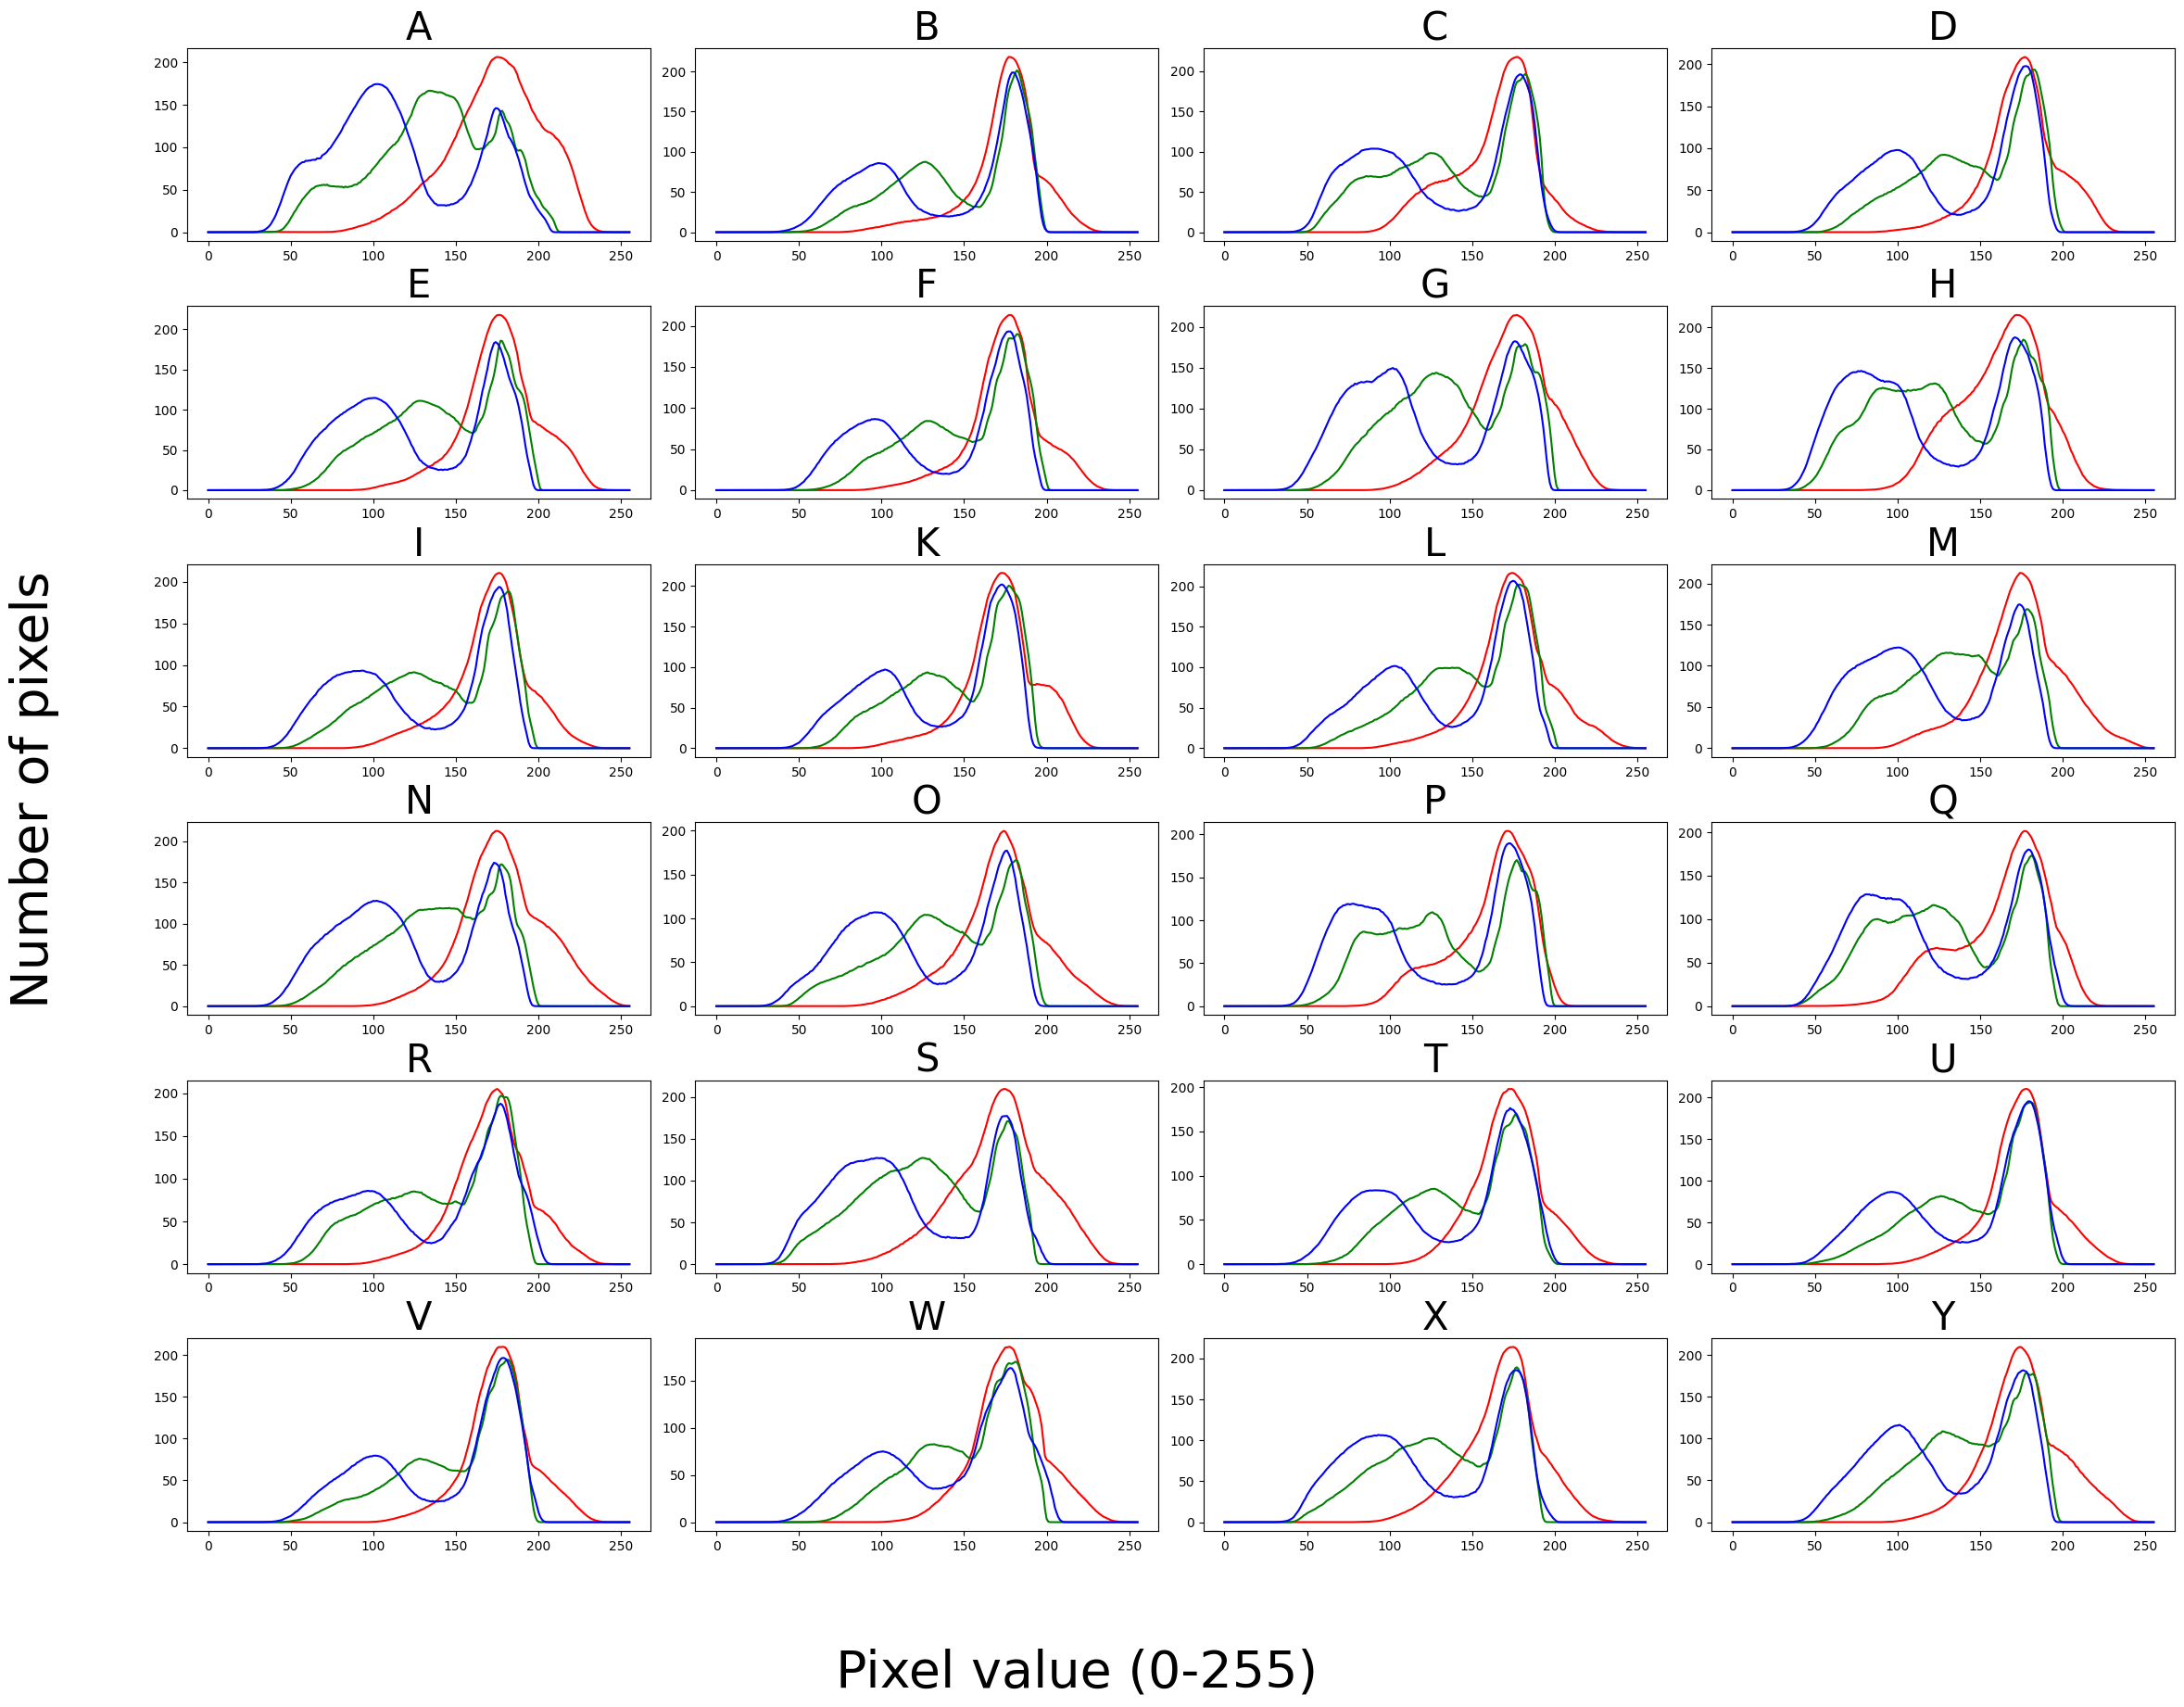

In [5]:
df_imgs = pd.read_csv(DIRECTORY_CSV)
dict_paths = {chr(i): [] for i in range(65, 90) if chr(i) != 'J'}

for img_file in os.listdir(DIRECTORY_IMG):
    if img_file.endswith(('.jpg', '.png')):
        name_img = img_file.split("/")[-1]
        name_label = df_imgs.loc[df_imgs['image'] == name_img, 'label'].values[0]
        dict_paths[name_label].append(os.path.join(DIRECTORY_IMG, img_file))

fig, axes = plt.subplots(6, 4, figsize=(24, 20))
for ax, (key, values) in zip(axes.flatten(), dict_paths.items()):
    r_hist = np.zeros(256)
    g_hist = np.zeros(256)
    b_hist = np.zeros(256)

    for i in values:
        image = Image.open(i)
        rgb_image = image.convert('RGB')
        r, g, b = np.array(rgb_image).T

        for value in r:
            r_hist[value] += 1
        for value in g:
            g_hist[value] += 1
        for value in b:
            b_hist[value] += 1

    num_images = len(values)
    r_hist /= num_images
    g_hist /= num_images
    b_hist /= num_images

    ax.plot(range(256), r_hist, color='red')
    ax.plot(range(256), g_hist, color='green')
    ax.plot(range(256), b_hist, color='blue')

    ax.set_title(key, fontsize=30) 

fig.supxlabel('Pixel value (0-255)', fontsize=40)
fig.supylabel('Number of pixels', fontsize=40)

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1)
fig.savefig("/kaggle/working/histogram.png")
plt.show()


## Cantidad de capas de cada individuo

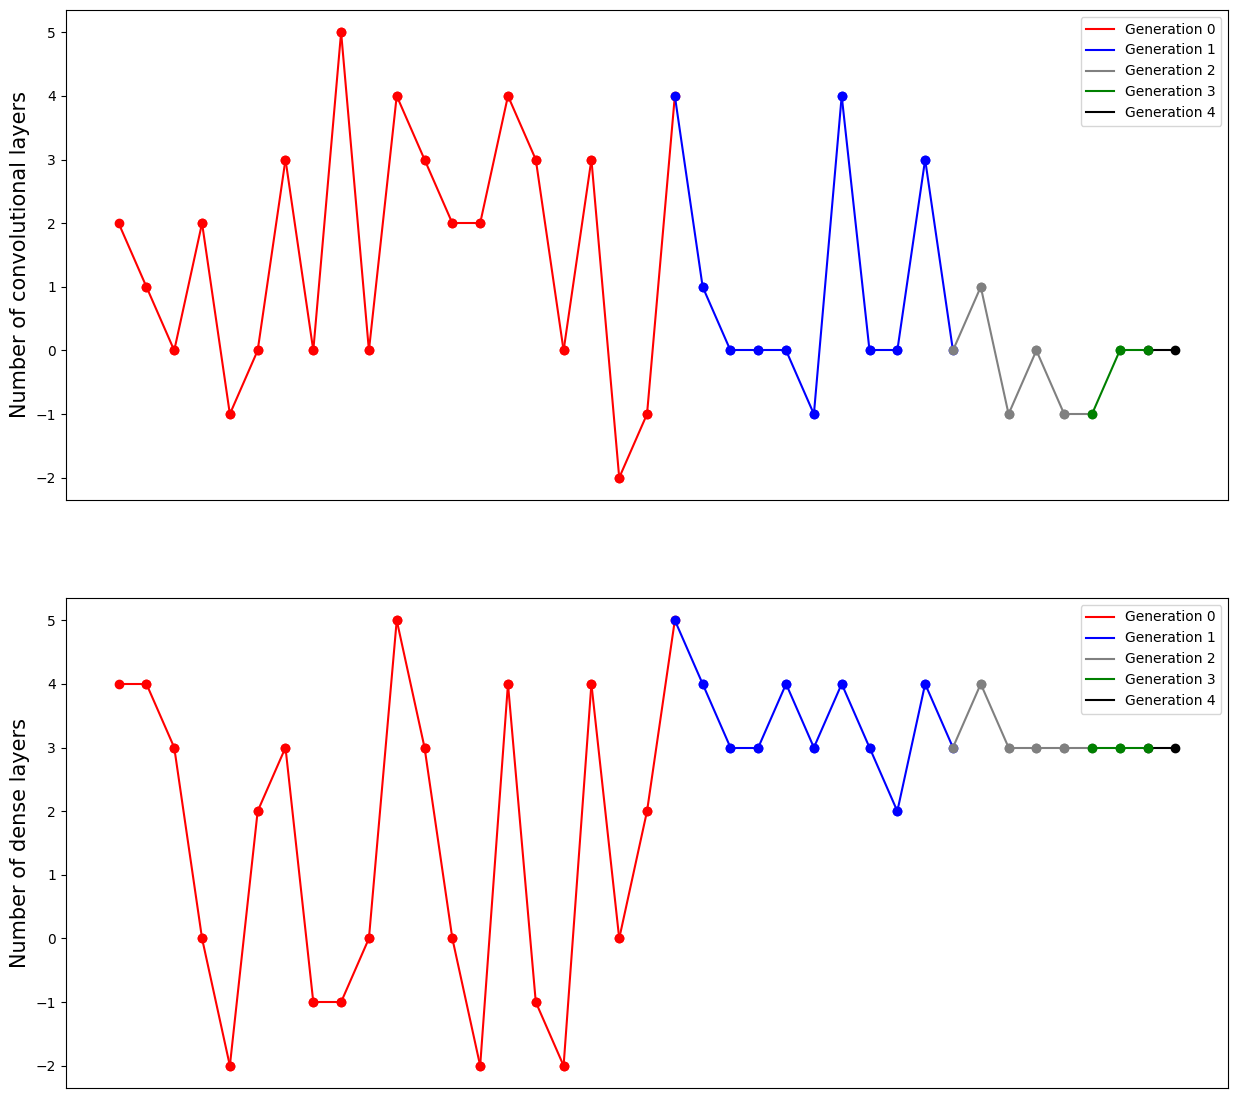

In [13]:
values_cnn = np.array(DF_GENERATIONS['n_cnn'])
values_dense = np.array(DF_GENERATIONS['n_dense'])
generations = np.array(DF_GENERATIONS['generation'])
indexes = np.arange(len(values_cnn))

colors = ['red', 'blue', 'gray', 'green', 'black']

fig, ax = plt.subplots(2, 1, figsize=(15,14))

ax[0].plot([indexes[-2], indexes[-1]], [values_cnn[-2], values_cnn[-1]], marker='o', linestyle='-', color='black')
ax[1].plot([indexes[-2], indexes[-1]], [values_dense[-2], values_dense[-1]], marker='o', linestyle='-', color='black')

for i in range(len(values_cnn) - 2):
    color = colors[generations[i]]
    ax[0].plot([indexes[i], indexes[i + 1]], [values_cnn[i], values_cnn[i + 1]], marker='o', linestyle='-', color=color)
    ax[0].set_ylabel("Number of convolutional layers", fontsize=15)

    ax[1].plot([indexes[i], indexes[i + 1]], [values_dense[i], values_dense[i + 1]], marker='o', linestyle='-', color=color)
    ax[1].set_ylabel("Number of dense layers", fontsize=15)

ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].yaxis.set_major_locator(MaxNLocator(integer=True))

ax[0].set_xticks([])
ax[1].set_xticks([])

legend_list = [plt.Line2D([0], [0], color=colors[i], label=f'Generation {i}') for i in range(len(colors))]
ax[0].legend(handles=legend_list)
ax[1].legend(handles=legend_list)

plt.show()


## Metricas de cada individuo

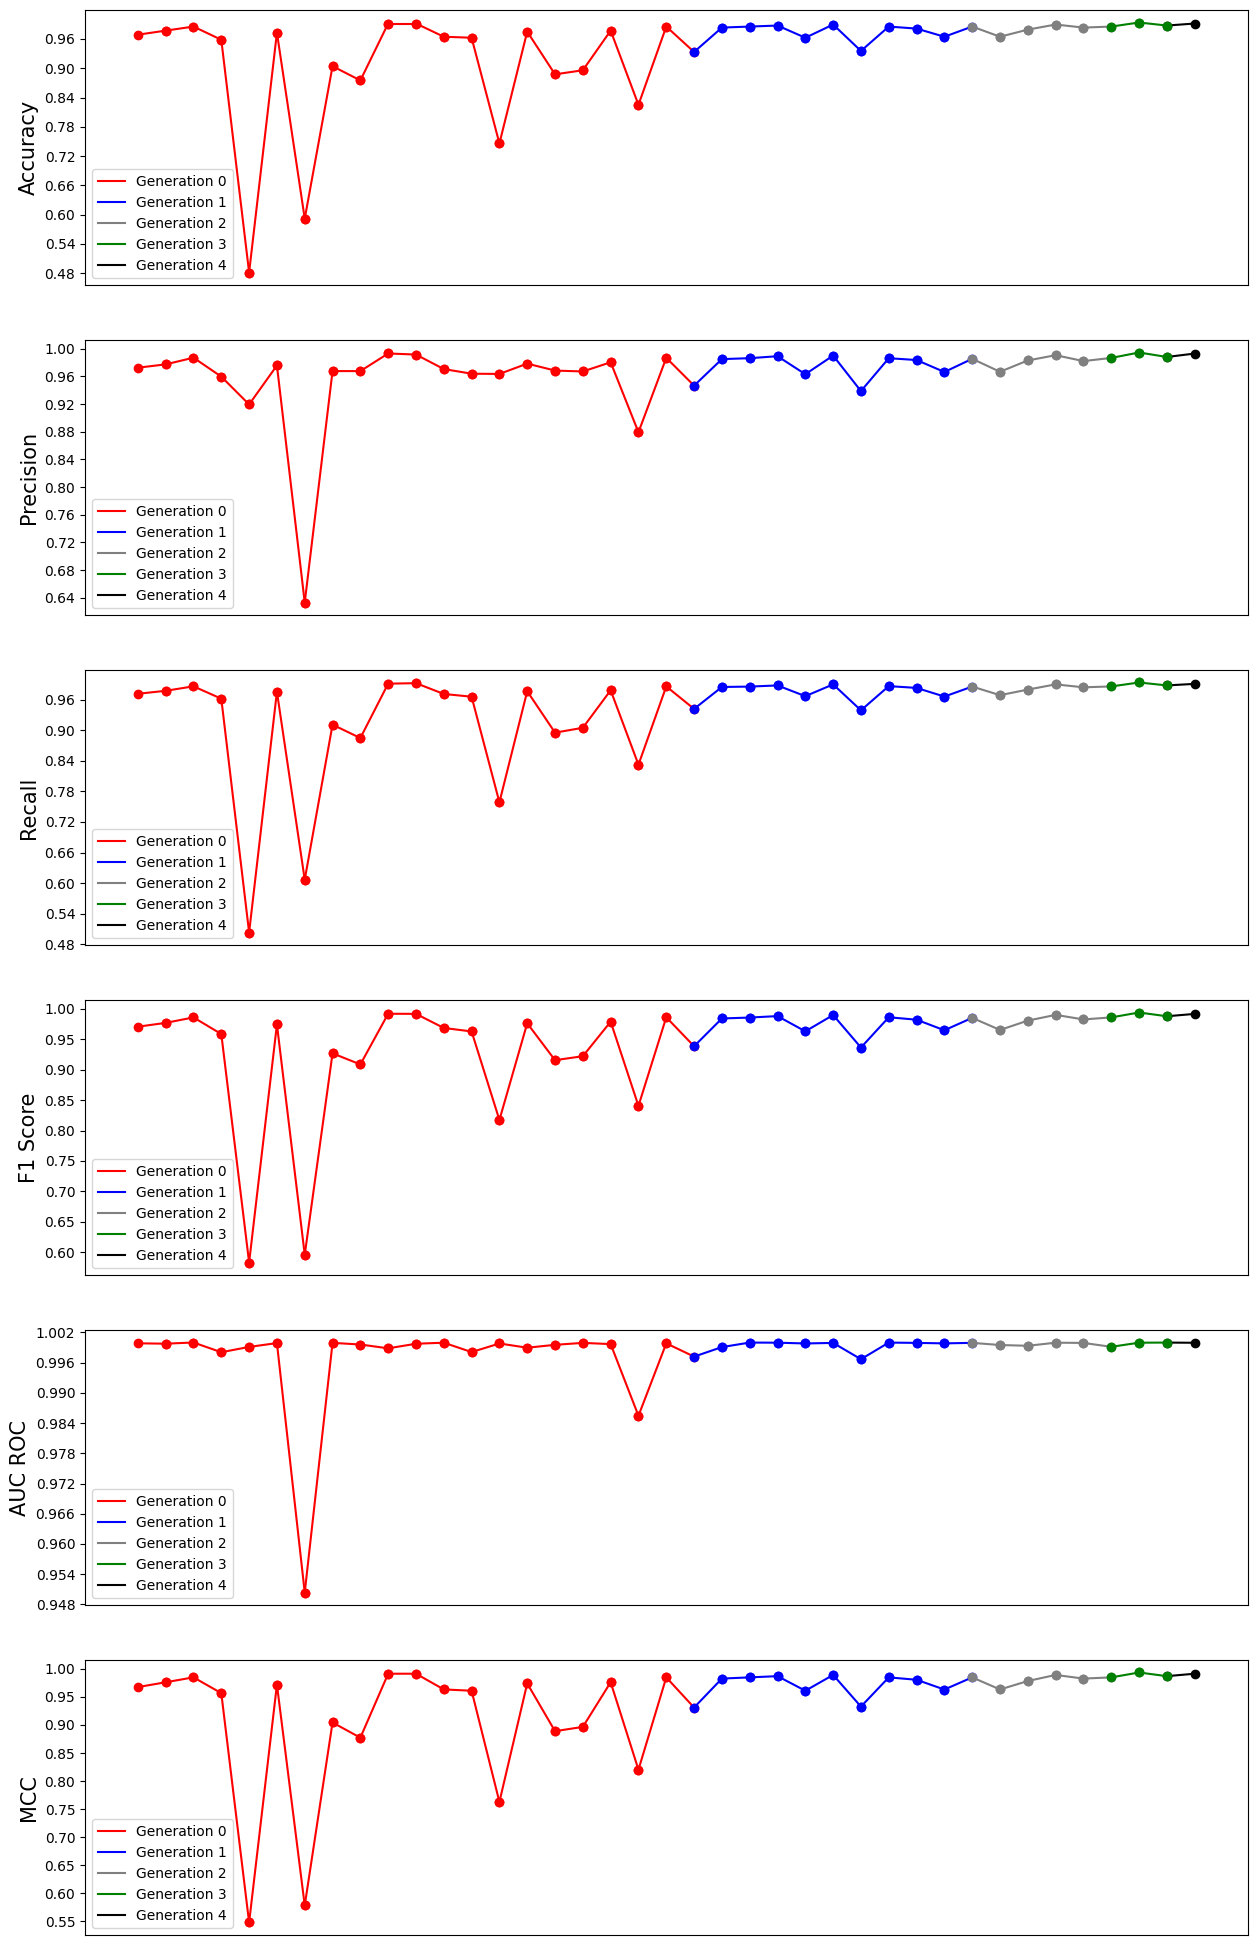

In [10]:
values = {
    'Accuracy': np.array(DF_RESULTS['accuracy']),
    'Precision': np.array(DF_RESULTS['precision']),
    'Recall': np.array(DF_RESULTS['recall']),
    'F1 Score': np.array(DF_RESULTS['f1_score']),
    'AUC ROC': np.array(DF_RESULTS['AUC_ROC']),
    'MCC': np.array(DF_RESULTS['MCC'])
}

generations = np.array(DF_RESULTS['generation'])
indexes = np.arange(len(generations))

colors = ['red', 'blue', 'gray', 'green', 'black']

fig, ax = plt.subplots(6, 1, figsize=(15, 25))

legend_list = [plt.Line2D([0], [0], color=colors[i], label=f'Generation {i}') for i in range(len(colors))]

for i, (name, values_list) in enumerate(values.items()):
    ax[i].plot([indexes[-2], indexes[-1]], [values_list[-2], values_list[-1]], marker='o', linestyle='-', color='black')

    for j in range(len(values_list) - 2):
        color = colors[generations[j]]
        ax[i].plot([indexes[j], indexes[j + 1]], [values_list[j], values_list[j + 1]], marker='o', linestyle='-', color=color)
        ax[i].set_ylabel(f"{name}", fontsize=15)

    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].set_xticks([])
    ax[i].legend(handles=legend_list)

plt.show()


## Metrica promedio de cada combinacion

c:\Users\Rudy\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\Rudy\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\Rudy\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\Rudy\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, Extensio

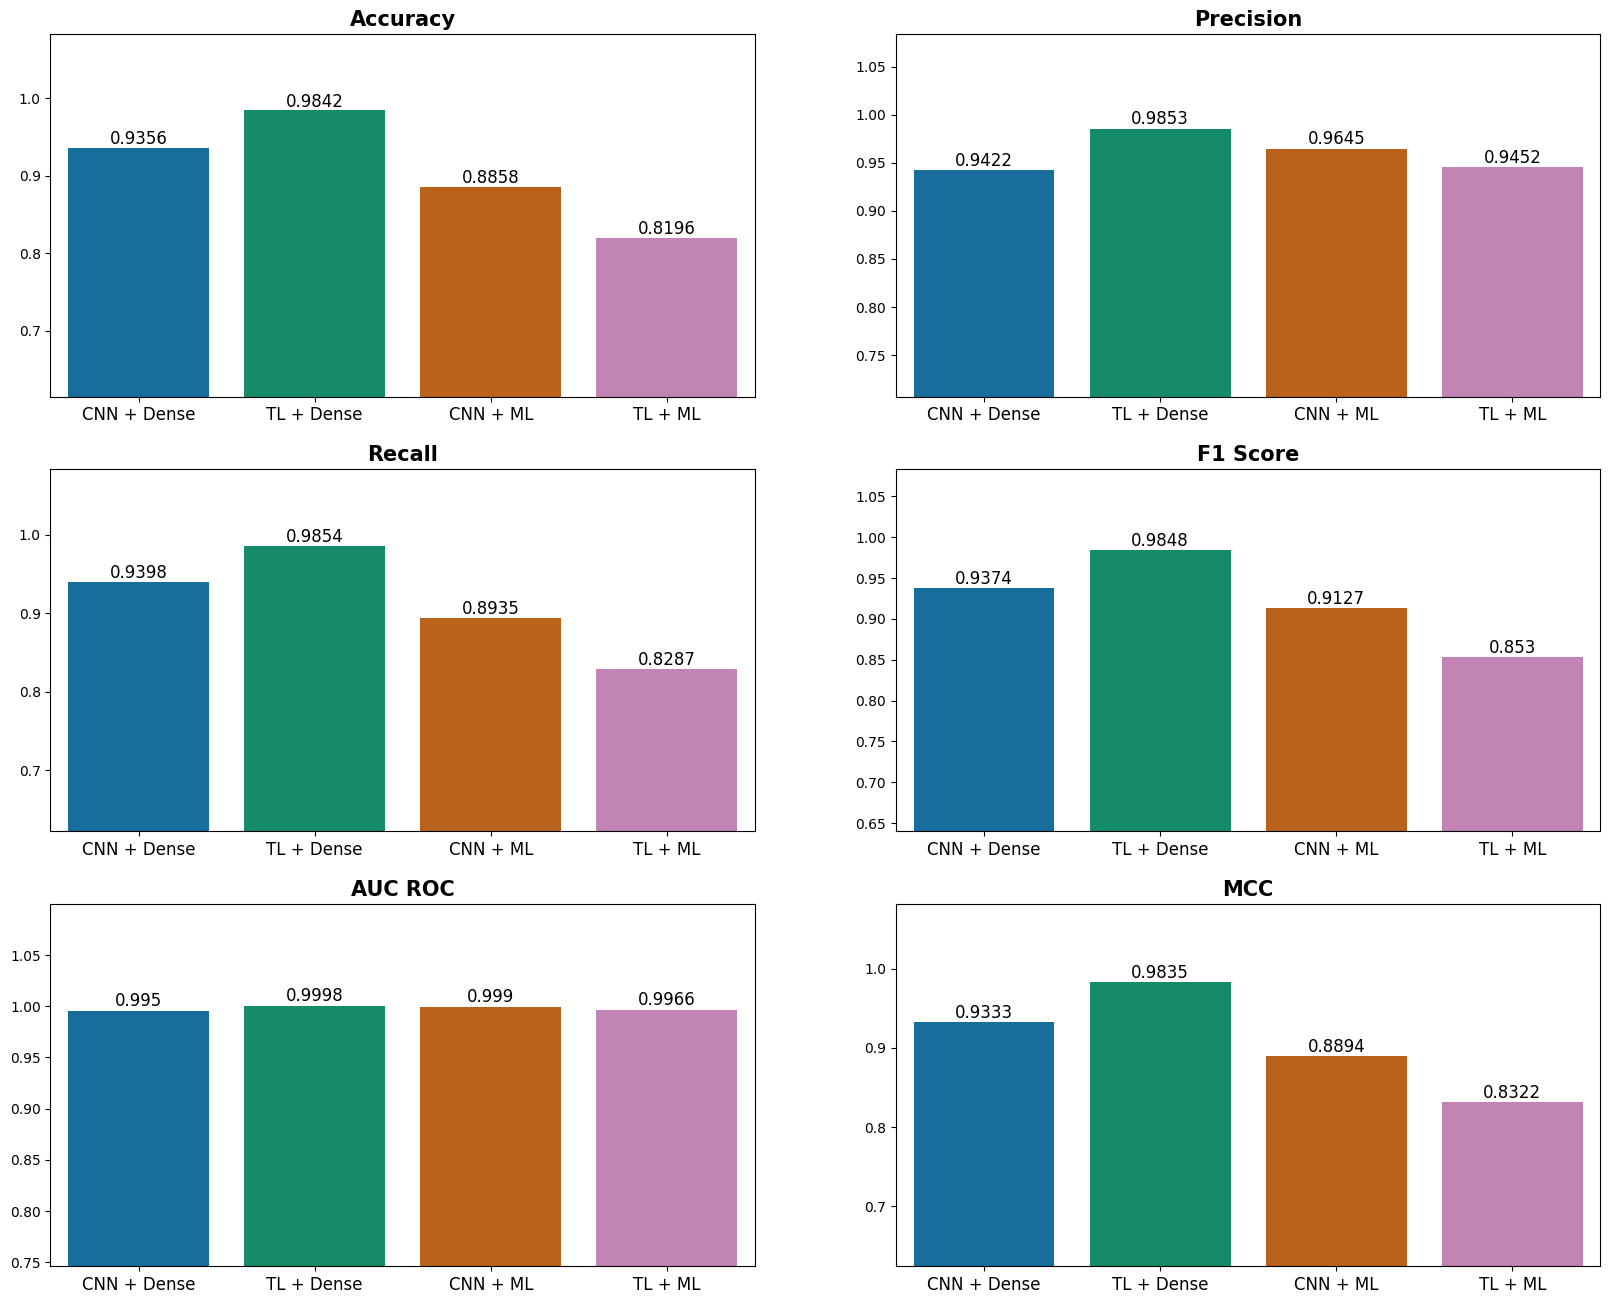

In [15]:
algorithms = {
    "CNN + Dense": DF_RESULTS[(DF_RESULTS['n_cnn'] > 0) & (DF_RESULTS['n_dense'] > 0)],
    "TL + Dense": DF_RESULTS[(DF_RESULTS['n_cnn'] <= 0) & (DF_RESULTS['n_dense'] > 0)],
    "CNN + ML": DF_RESULTS[(DF_RESULTS['n_cnn'] > 0) & (DF_RESULTS['n_dense'] <= 0)],
    "TL + ML": DF_RESULTS[(DF_RESULTS['n_cnn'] <= 0) & (DF_RESULTS['n_dense'] <= 0)]
}

metrics = ["accuracy", "precision", "recall", "f1_score", "AUC_ROC", "MCC"]
metrics_title = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC ROC", "MCC"]
colors = sns.color_palette("colorblind6", len(algorithms))

fig, axes = plt.subplots(3, 2, figsize=(20,16))
axes = axes.flatten()

algorithms_names = list(algorithms.keys())
for i, metric in enumerate(metrics):
    values = [round(np.mean(value[metric]), 4)for value in algorithms.values()]
    sns.barplot(x=algorithms_names, y=values, palette=colors, ax=axes[i])

    for j, v in enumerate(values):
        axes[i].text(j, v + 0.005, str(v), ha="center", fontsize=12)

    axes[i].set_xticklabels(algorithms_names, fontsize=12)
    axes[i].set_title(metrics_title[i], fontsize=15, fontweight="bold")
    axes[i].set_ylim(min(values) * 0.75, max(values) * 1.1)

plt.savefig("figura 6.png")
plt.show()

# K fold

## Algoritmo

In [11]:
DATASET = get_data(img_per_label=200)

x_train = DATASET["x_train"]
x_test = DATASET["x_test"]
y_train = DATASET["y_train"]    
y_test = DATASET["y_test"]

In [12]:
def create_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(100, 100, 3))
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)

    x = Dense(256, activation='relu')(x)

    x = Dense(128, activation='relu')(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    x = Dense(y_train.shape[1], activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=x)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

## Graficos

In [13]:
def accuracy_epocs(directory_fold, history_list):
    epochs = [i for i in range(20)]
    fig, ax = plt.subplots(4, 2, figsize=(10, 20))

    for i, history in enumerate(history_list):
        train_acc = history["accuracy"]
        train_loss = history["loss"]

        val_acc = history["val_accuracy"]
        val_loss = history["val_loss"]

        ax[i, 0].plot(epochs, train_acc, "yo-", label ="train_accuracy")
        ax[i, 0].plot(epochs, val_acc, "co-", label= "val_accuracy")
        ax[i, 0].set_title(f"Accuracy fold {i + 1}", fontsize=16, fontweight="bold")
        ax[i, 0].legend()
        ax[i, 0].set_xlabel("Epochs", fontsize=12)
        ax[i, 0].set_ylabel("Accuracy", fontsize=12)
        ax[i, 0].xaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax[i, 1].plot(epochs, train_loss, "yo-", label ="train_loss")
        ax[i, 1].plot(epochs, val_loss, "co-", label= "val_loss")
        ax[i, 1].set_title(f"Loss fold {i + 1}", fontsize=16, fontweight="bold")
        ax[i, 1].legend()
        ax[i, 1].set_xlabel("Epochs", fontsize=12)
        ax[i, 1].set_ylabel("Loss", fontsize=12)
        ax[i, 1].xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(f"{directory_fold}/accuracy_epochs.png")
    plt.close()

In [14]:
def metrics_fold(directory_fold, y_true_list, y_pred_list, y_prob_list, times_list):
    fold_errors_labels = []
    fold_train = []
    
    for fold in range(4):
        total_errors = 0
        y_true = y_true_list[fold]
        y_pred = y_pred_list[fold]
        y_prob = y_prob_list[fold]
        for label in np.unique(y_true):
            label_mask = (y_true == label)
            false_negatives = np.sum((y_true == label) & (y_pred != label))
            false_positives = np.sum((y_true != label) & (y_pred == label))
            errors = false_negatives + false_positives
            total_errors += errors
            
            acc = accuracy_score(label_mask, y_pred == label)
            prec = precision_score(label_mask, y_pred == label, zero_division=0)
            rec = recall_score(label_mask, y_pred == label, zero_division=0)
            f1 = f1_score(label_mask, y_pred == label, zero_division=0)

            fold_errors_labels.append({
                'Fold': fold + 1, 'Label': LABELS_SIGN[label], 'Errors': errors,
                'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1
            })
    
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_true, y_pred)
        
        fold_train.append({
            'Fold': fold + 1, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
            'ROC AUC': auc, 'MCC': mcc, 'Time': times_list[fold], 'errors': total_errors
        })
    
    k_fold_labels = pd.DataFrame(fold_errors_labels)
    k_fold_labels.to_csv(f"{directory_fold}/k_fold_labels.csv", index=False)
    
    k_fold_train = pd.DataFrame(fold_train)
    k_fold_train.to_csv(f"{directory_fold}/k_fold_train.csv", index=False)

In [15]:
def confusion_matrix_fold(directory_fold, y_true_list, y_pred_list):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for fold in range(4):
        ax = axes[fold]
        y_true = y_true_list[fold]
        y_pred = y_pred_list[fold]

        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                    xticklabels=LABELS_SIGN, yticklabels=LABELS_SIGN, ax=ax)
        ax.set_xlabel('Prediction', fontsize=12)
        ax.set_ylabel('Real', fontsize=12)
        ax.set_title(f'Fold {fold + 1}', fontsize=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f'{directory_fold}/confusion_matrix.png')
    plt.close()
        
def roc_fold(directory_fold, y_true_list, y_prob_list):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for fold in range(4):
        ax = axes[fold]
        y_true = y_true_list[fold]
        y_prob = y_prob_list[fold]
        for i, _ in enumerate(LABELS_SIGN):
            fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
            ax.plot(fpr, tpr, lw=2)
            
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
        ax.set_title(f'Fold {fold + 1}', fontsize=16, fontweight="bold")
        ax.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f'{directory_fold}/curve_roc.png')
    plt.close()

## Entrenamiento

In [16]:
directory_fold = "/kaggle/working/kfold"
os.makedirs(directory_fold, exist_ok=True)

kf = KFold(n_splits=4, shuffle=True, random_state=42)
scores = []
fold_errors = []
history_list = []
times_list = []
y_true_list, y_pred_list, y_prob_list = [], [], []

for fold, (train_index, val_index) in enumerate(kf.split(x_train)):
    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    model = create_model()
    
    initial_time = time.time()
    history = model.fit(x_train_fold, y_train_fold, epochs=20, batch_size=32, validation_data=(x_val_fold, y_val_fold), verbose=0)
    final_time = time.time()

    score = model.evaluate(x_val_fold, y_val_fold, verbose=0)
    scores.append(score[1])

    y_prob = model.predict(x_val_fold, verbose=0)
    y_true = np.argmax(y_val_fold, axis=1)
    y_pred = np.argmax(y_prob, axis=1)

    y_true_list.append(y_true)
    y_pred_list.append(y_pred)
    y_prob_list.append(y_prob)
    times_list.append(final_time - initial_time)
    history_list.append(history.history)

    print(f"Accuracy in fold {fold + 1}: {score[1]}")

metrics_fold(directory_fold, y_true_list, y_pred_list, y_prob_list, times_list)
accuracy_epocs(directory_fold, history_list)
confusion_matrix_fold(directory_fold, y_true_list, y_pred_list)
roc_fold(directory_fold, y_true_list, y_prob_list)

print(f'\nAverage accuracy in 5 folds: {np.mean(scores):.4f}')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Accuracy in fold 1: 0.9937499761581421
Accuracy in fold 2: 0.9958333373069763
Accuracy in fold 3: 1.0
Accuracy in fold 4: 0.9937499761581421

Average accuracy in 5 folds: 0.9958
